# 🎬 YouTube Recommender — ML Pipeline Prototype

This notebook walks through the full recommendation pipeline step by step:

1. **Mock Data** — simulate liked videos + subscribed channels
2. **Embedding** — encode titles using `all-MiniLM-L6-v2`
3. **User Vector** — mean pool liked titles + channel descriptions
4. **Video Pool** — simulate the revolving pool of candidate videos
5. **Cosine Similarity** — rank pool videos against user vector
6. **Diversity Filter** — ensure varied channels in results
7. **Visualise** — plot similarity scores

> Run each cell in order. No YouTube API key needed — all data is mocked for prototyping.

## 📦 Cell 1 — Install Dependencies

In [1]:
# Run this once to install required packages
!pip install sentence-transformers scikit-learn numpy pandas matplotlib seaborn

## 📥 Cell 2 — Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

print('✅ All imports successful')

✅ All imports successful


## 🤖 Cell 3 — Load Embedding Model

We use `all-MiniLM-L6-v2` — a lightweight 80MB model that produces 384-dimensional vectors.
Downloads automatically on first run, then cached locally.

In [3]:
print('Loading all-MiniLM-L6-v2 ...')
model = SentenceTransformer('all-MiniLM-L6-v2')
print(f'✅ Model loaded — output dimensions: {model.get_sentence_embedding_dimension()}')

Loading all-MiniLM-L6-v2 ...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Model loaded — output dimensions: 384


## 🎭 Cell 4 — Mock User Data

Simulates what we'd get from the YouTube API:
- `liked_videos` → from `youtube.videos().list(myRating=like)`
- `subscribed_channels` → from `youtube.subscriptions().list(mine=True)`

**Swap these lists with real API data when integrating into FastAPI.**

In [4]:
# ── Simulated liked video titles ──────────────────────────────────────────────
liked_videos = [
    {"title": "Python FastAPI Tutorial for Beginners", "video_id": "v001", "channel": "Tech With Tim"},
    {"title": "Machine Learning Full Course 2024", "video_id": "v002", "channel": "freeCodeCamp"},
    {"title": "Build a REST API with FastAPI", "video_id": "v003", "channel": "Traversy Media"},
    {"title": "Deep Learning with PyTorch - Complete Course", "video_id": "v004", "channel": "freeCodeCamp"},
    {"title": "Docker for Beginners - Full Course", "video_id": "v005", "channel": "TechWorld with Nana"},
    {"title": "LLMs Explained - How ChatGPT Works", "video_id": "v006", "channel": "Andrej Karpathy"},
    {"title": "Vector Databases Explained", "video_id": "v007", "channel": "IBM Technology"},
    {"title": "Transformers Architecture from Scratch", "video_id": "v008", "channel": "Andrej Karpathy"},
]

# ── Simulated subscribed channel descriptions ─────────────────────────────────
subscribed_channels = [
    {"name": "Tech With Tim",        "description": "Python programming tutorials, machine learning, game development and software engineering"},
    {"name": "freeCodeCamp",         "description": "Free coding tutorials covering web development, data science, machine learning and algorithms"},
    {"name": "Andrej Karpathy",      "description": "Deep learning, neural networks, AI research, GPT and large language model tutorials"},
    {"name": "Traversy Media",       "description": "Web development tutorials including JavaScript, Python, APIs and backend development"},
    {"name": "TechWorld with Nana",  "description": "DevOps tutorials covering Docker, Kubernetes, CI/CD pipelines and cloud infrastructure"},
]

liked_titles = [v['title'] for v in liked_videos]
channel_descriptions = [c['description'] for c in subscribed_channels]

print(f'✅ Liked videos     : {len(liked_titles)}')
print(f'✅ Subscribed channels: {len(channel_descriptions)}')
print(f'\nSample liked title : "{liked_titles[0]}"')
print(f'Sample channel desc: "{channel_descriptions[0]}"')

✅ Liked videos     : 8
✅ Subscribed channels: 5

Sample liked title : "Python FastAPI Tutorial for Beginners"
Sample channel desc: "Python programming tutorials, machine learning, game development and software engineering"


## 👤 Cell 5 — Build User Vector

Strategy: embed all liked titles + channel descriptions, then **mean pool** into a single 384-dim vector.

This vector represents the user's overall taste in embedding space.

In [5]:
all_user_texts = liked_titles + channel_descriptions
print(f'Total texts to embed for user profile: {len(all_user_texts)}')

# Embed all user texts
user_embeddings = model.encode(all_user_texts, convert_to_numpy=True, show_progress_bar=True)
print(f'\nEmbeddings shape: {user_embeddings.shape}')  # (13, 384)

# Mean pool → single user vector
user_vector = np.mean(user_embeddings, axis=0)
print(f'User vector shape: {user_vector.shape}')        # (384,)
print(f'User vector norm : {np.linalg.norm(user_vector):.4f}')
print('\n✅ User vector built successfully')

Total texts to embed for user profile: 13


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Embeddings shape: (13, 384)
User vector shape: (384,)
User vector norm : 0.5329

✅ User vector built successfully


## 🎱 Cell 6 — Build Mock Video Pool

Simulates what `pool_service.py` fetches from YouTube API:
- Trending videos
- Channel uploads
- Search results

In production this pool would have ~250 real videos refreshed on each request.

In [6]:
video_pool = [
    # ── Relevant (should score HIGH) ──────────────────────────────────────────
    {"title": "FastAPI with PostgreSQL - Build a Full Stack App",     "channel": "Tech With Tim",       "video_id": "p001"},
    {"title": "Sentence Transformers Tutorial - NLP with Python",     "channel": "James Briggs",        "video_id": "p002"},
    {"title": "RAG Pipeline from Scratch using LangChain",            "channel": "Sam Witteveen",       "video_id": "p003"},
    {"title": "PyTorch Neural Network Tutorial",                       "channel": "Patrick Loeber",     "video_id": "p004"},
    {"title": "Kubernetes Full Course for Beginners",                  "channel": "TechWorld with Nana","video_id": "p005"},
    {"title": "Fine-tuning LLMs with LoRA Explained",                 "channel": "Andrej Karpathy",    "video_id": "p006"},
    {"title": "Deploying FastAPI on AWS Lambda",                      "channel": "Traversy Media",     "video_id": "p007"},
    {"title": "Introduction to Vector Embeddings",                    "channel": "IBM Technology",     "video_id": "p008"},
    {"title": "Python Data Classes Tutorial",                         "channel": "Tech With Tim",      "video_id": "p009"},
    {"title": "MLOps Full Course - From Model to Production",         "channel": "freeCodeCamp",       "video_id": "p010"},

    # ── Partially relevant (should score MEDIUM) ───────────────────────────────
    {"title": "JavaScript Async Await Tutorial",                      "channel": "Traversy Media",     "video_id": "p011"},
    {"title": "SQL for Data Science - Complete Guide",                "channel": "freeCodeCamp",       "video_id": "p012"},
    {"title": "Linux Command Line for Beginners",                     "channel": "NetworkChuck",       "video_id": "p013"},
    {"title": "Cloud Computing Explained - AWS vs Azure vs GCP",      "channel": "IBM Technology",     "video_id": "p014"},

    # ── Irrelevant (should score LOW) ─────────────────────────────────────────
    {"title": "Top 10 Street Foods in Mumbai",                        "channel": "Food Ranger",        "video_id": "p015"},
    {"title": "IPL 2024 Highlights - MI vs CSK",                      "channel": "Star Sports",        "video_id": "p016"},
    {"title": "Bollywood Dance Tutorial for Beginners",               "channel": "BollyFlex",          "video_id": "p017"},
    {"title": "Minecraft Survival Guide Episode 1",                   "channel": "Pixlriffs",          "video_id": "p018"},
    {"title": "Best Budget Smartphones Under 15000 in India 2024",    "channel": "Technical Guruji",   "video_id": "p019"},
    {"title": "Yoga for Stress Relief - 30 Minute Session",           "channel": "Yoga with Adriene",  "video_id": "p020"},
]

print(f'✅ Video pool size: {len(video_pool)} videos')
print(f'\nPool breakdown:')
print(f'  Relevant (ML/Python/API)  : 10 videos')
print(f'  Partially relevant (tech) : 4 videos')
print(f'  Irrelevant (food/sports)  : 6 videos')

✅ Video pool size: 20 videos

Pool breakdown:
  Relevant (ML/Python/API)  : 10 videos
  Partially relevant (tech) : 4 videos
  Irrelevant (food/sports)  : 6 videos


## 🔢 Cell 7 — Embed Pool Titles

In [7]:
pool_titles = [v['title'] for v in video_pool]

print('Embedding pool titles...')
pool_embeddings = model.encode(pool_titles, convert_to_numpy=True, show_progress_bar=True)

print(f'\nPool embeddings shape: {pool_embeddings.shape}')  # (20, 384)
print('✅ Pool embeddings ready')

Embedding pool titles...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Pool embeddings shape: (20, 384)
✅ Pool embeddings ready


## 📐 Cell 8 — Cosine Similarity

Measures how closely each pool video's embedding aligns with the user's taste vector.
Score range: -1 (opposite) to 1 (identical). Typically 0.2–0.7 for good matches.

In [8]:
# Compute similarity between user vector and all pool videos
scores = cosine_similarity([user_vector], pool_embeddings)[0]

# Attach scores to pool videos
for i, video in enumerate(video_pool):
    video['similarity_score'] = float(scores[i])

# Sort by score descending
ranked_pool = sorted(video_pool, key=lambda x: x['similarity_score'], reverse=True)

# Display as DataFrame
df = pd.DataFrame(ranked_pool)[['title', 'channel', 'similarity_score']]
df['similarity_score'] = df['similarity_score'].round(4)
df.index = range(1, len(df) + 1)

print('📊 Full ranked pool:\n')
pd.set_option('display.max_colwidth', 60)
print(df.to_string())

📊 Full ranked pool:

                                                title              channel  similarity_score
1                     PyTorch Neural Network Tutorial       Patrick Loeber            0.5730
2                        Python Data Classes Tutorial        Tech With Tim            0.5517
3                Kubernetes Full Course for Beginners  TechWorld with Nana            0.5183
4                    Linux Command Line for Beginners         NetworkChuck            0.4187
5        MLOps Full Course - From Model to Production         freeCodeCamp            0.4079
6              Bollywood Dance Tutorial for Beginners            BollyFlex            0.4071
7    Sentence Transformers Tutorial - NLP with Python         James Briggs            0.3868
8                   Introduction to Vector Embeddings       IBM Technology            0.3512
9               SQL for Data Science - Complete Guide         freeCodeCamp            0.3390
10   FastAPI with PostgreSQL - Build a Full Stack

## 🌈 Cell 9 — Diversity Filter

Without diversity filtering, the top-10 might be dominated by one channel.
We cap each channel at max 2 videos in the final recommendations.

In [9]:
def diversity_filter(ranked_videos, top_k=10, max_per_channel=2):
    """Pick top-K videos ensuring no single channel dominates."""
    channel_counts = {}
    result = []

    for video in ranked_videos:
        if len(result) >= top_k:
            break
        channel = video['channel']
        count = channel_counts.get(channel, 0)
        if count < max_per_channel:
            result.append(video)
            channel_counts[channel] = count + 1

    return result


recommendations = diversity_filter(ranked_pool, top_k=10, max_per_channel=2)

print(f'✅ Final {len(recommendations)} recommendations after diversity filter:\n')
for i, v in enumerate(recommendations, 1):
    print(f"{i:2}. [{v['similarity_score']:.4f}]  {v['title']}")
    print(f"     Channel: {v['channel']}")
    print()

✅ Final 10 recommendations after diversity filter:

 1. [0.5730]  PyTorch Neural Network Tutorial
     Channel: Patrick Loeber

 2. [0.5517]  Python Data Classes Tutorial
     Channel: Tech With Tim

 3. [0.5183]  Kubernetes Full Course for Beginners
     Channel: TechWorld with Nana

 4. [0.4187]  Linux Command Line for Beginners
     Channel: NetworkChuck

 5. [0.4079]  MLOps Full Course - From Model to Production
     Channel: freeCodeCamp

 6. [0.4071]  Bollywood Dance Tutorial for Beginners
     Channel: BollyFlex

 7. [0.3868]  Sentence Transformers Tutorial - NLP with Python
     Channel: James Briggs

 8. [0.3512]  Introduction to Vector Embeddings
     Channel: IBM Technology

 9. [0.3390]  SQL for Data Science - Complete Guide
     Channel: freeCodeCamp

10. [0.3263]  FastAPI with PostgreSQL - Build a Full Stack App
     Channel: Tech With Tim



## 🔑 Cell 10 — Keyword Extraction from Liked Titles

Extracts top recurring keywords from liked titles — used to generate YouTube search queries for the pool.

In [10]:
def extract_keywords(titles, top_n=10):
    """Simple frequency-based keyword extractor."""
    stopwords = {
        "the", "a", "an", "in", "on", "at", "to", "for", "of",
        "and", "or", "is", "are", "with", "how", "what", "your",
        "you", "my", "this", "that", "it", "i", "from", "by",
        "full", "course", "tutorial", "beginners", "complete"
    }
    words = []
    for title in titles:
        tokens = re.findall(r'\b[a-zA-Z]{3,}\b', title.lower())
        words += [w for w in tokens if w not in stopwords]

    return Counter(words).most_common(top_n)


keywords = extract_keywords(liked_titles)

print('🔑 Top keywords extracted from liked titles:\n')
for word, count in keywords:
    bar = '█' * count
    print(f"  {word:<20} {bar} ({count})")

top_search_queries = [word for word, _ in keywords[:5]]
print(f'\n➡️  Top search queries for pool: {top_search_queries}')

🔑 Top keywords extracted from liked titles:

  fastapi              ██ (2)
  learning             ██ (2)
  explained            ██ (2)
  python               █ (1)
  machine              █ (1)
  build                █ (1)
  rest                 █ (1)
  api                  █ (1)
  deep                 █ (1)
  pytorch              █ (1)

➡️  Top search queries for pool: ['fastapi', 'learning', 'explained', 'python', 'machine']


## 📊 Cell 11 — Visualise Similarity Scores

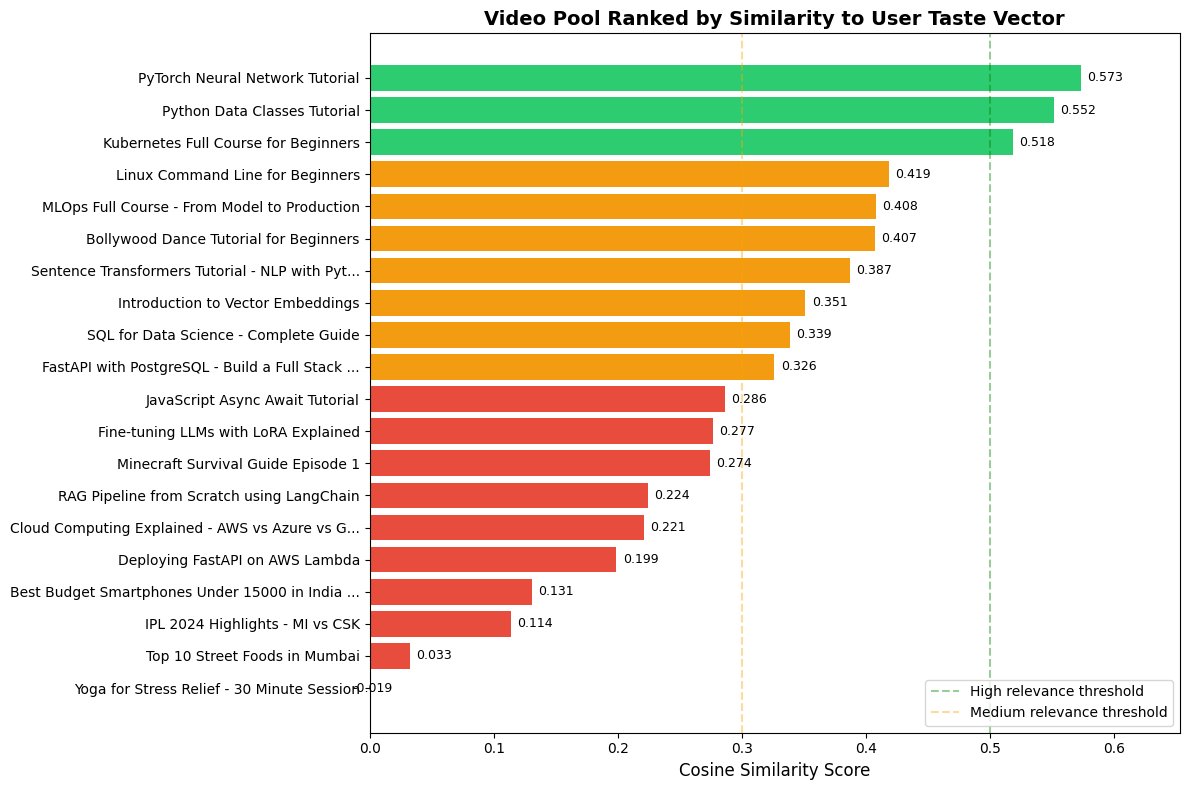

✅ Chart saved as similarity_scores.png


In [11]:
df_ranked = pd.DataFrame(ranked_pool)

# Truncate long titles for display
df_ranked['short_title'] = df_ranked['title'].apply(lambda t: t[:45] + '...' if len(t) > 45 else t)

# Color by relevance tier
def color_tier(score):
    if score >= 0.5:  return '#2ecc71'  # green  — high
    if score >= 0.3:  return '#f39c12'  # orange — medium
    return '#e74c3c'                     # red    — low

colors = df_ranked['similarity_score'].apply(color_tier)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(df_ranked['short_title'], df_ranked['similarity_score'], color=colors)

# Add score labels
for bar, score in zip(bars, df_ranked['similarity_score']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{score:.3f}', va='center', fontsize=9)

ax.invert_yaxis()
ax.set_xlabel('Cosine Similarity Score', fontsize=12)
ax.set_title('Video Pool Ranked by Similarity to User Taste Vector', fontsize=14, fontweight='bold')
ax.axvline(x=0.5, color='green', linestyle='--', alpha=0.4, label='High relevance threshold')
ax.axvline(x=0.3, color='orange', linestyle='--', alpha=0.4, label='Medium relevance threshold')
ax.legend(loc='lower right')
ax.set_xlim(0, max(df_ranked['similarity_score']) + 0.08)

plt.tight_layout()
plt.savefig('similarity_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved as similarity_scores.png')

## 🔥 Cell 12 — Heatmap: Liked Titles vs Top Recommendations

Shows pairwise similarity between each liked title and each recommended video — useful for understanding *why* each recommendation was made.

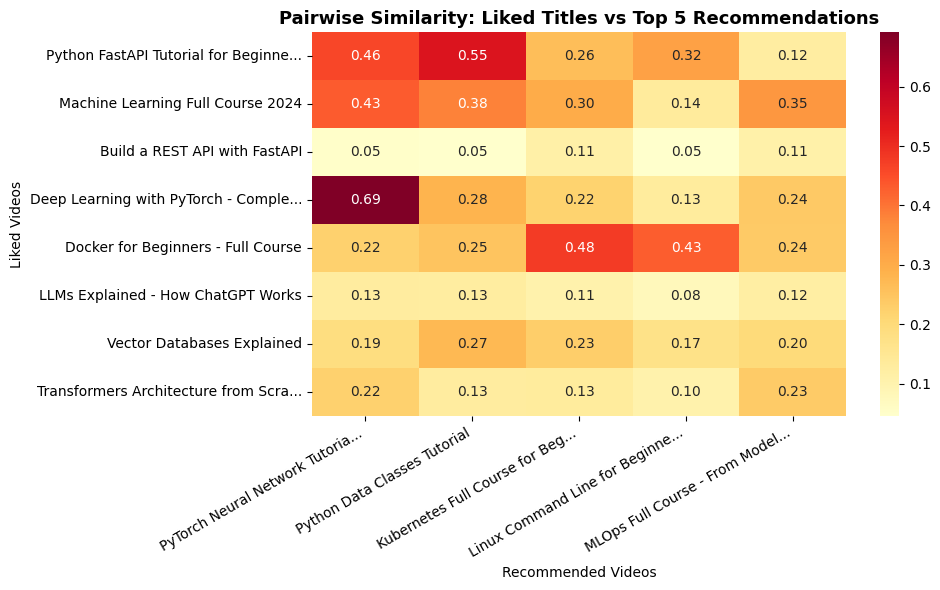

✅ Heatmap saved as similarity_heatmap.png


In [12]:
top5_recs = recommendations[:5]
rec_titles = [v['title'] for v in top5_recs]

# Embed liked titles and top rec titles separately
liked_embs = model.encode(liked_titles, convert_to_numpy=True)
rec_embs   = model.encode(rec_titles,   convert_to_numpy=True)

# Pairwise similarity matrix: (liked x recs)
sim_matrix = cosine_similarity(liked_embs, rec_embs)

# Truncate labels
liked_labels = [t[:35] + '...' if len(t) > 35 else t for t in liked_titles]
rec_labels   = [t[:30] + '...' if len(t) > 30 else t for t in rec_titles]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    sim_matrix,
    xticklabels=rec_labels,
    yticklabels=liked_labels,
    annot=True, fmt='.2f',
    cmap='YlOrRd',
    ax=ax
)
ax.set_title('Pairwise Similarity: Liked Titles vs Top 5 Recommendations', fontsize=13, fontweight='bold')
ax.set_xlabel('Recommended Videos')
ax.set_ylabel('Liked Videos')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Heatmap saved as similarity_heatmap.png')

## ✅ Cell 13 — Final Output Summary

Clean final output — this is what `GET /recommend` will return in FastAPI.

In [13]:
print('=' * 65)
print('  🎬  FINAL RECOMMENDATIONS')
print('=' * 65)

for i, v in enumerate(recommendations, 1):
    print(f"\n#{i}  {v['title']}")
    print(f"    Channel : {v['channel']}")
    print(f"    Score   : {v['similarity_score']:.4f}")
    print(f"    URL     : https://youtube.com/watch?v={v['video_id']}")

print('\n' + '=' * 65)
print(f'  Total: {len(recommendations)} recommendations from pool of {len(video_pool)}')
print('=' * 65)

  🎬  FINAL RECOMMENDATIONS

#1  PyTorch Neural Network Tutorial
    Channel : Patrick Loeber
    Score   : 0.5730
    URL     : https://youtube.com/watch?v=p004

#2  Python Data Classes Tutorial
    Channel : Tech With Tim
    Score   : 0.5517
    URL     : https://youtube.com/watch?v=p009

#3  Kubernetes Full Course for Beginners
    Channel : TechWorld with Nana
    Score   : 0.5183
    URL     : https://youtube.com/watch?v=p005

#4  Linux Command Line for Beginners
    Channel : NetworkChuck
    Score   : 0.4187
    URL     : https://youtube.com/watch?v=p013

#5  MLOps Full Course - From Model to Production
    Channel : freeCodeCamp
    Score   : 0.4079
    URL     : https://youtube.com/watch?v=p010

#6  Bollywood Dance Tutorial for Beginners
    Channel : BollyFlex
    Score   : 0.4071
    URL     : https://youtube.com/watch?v=p017

#7  Sentence Transformers Tutorial - NLP with Python
    Channel : James Briggs
    Score   : 0.3868
    URL     : https://youtube.com/watch?v=p002

#

## 🚀 Next Steps

Once you're happy with the pipeline here, wire it into FastAPI:

| Notebook Cell | FastAPI File |
|---|---|
| Model loading (Cell 3) | `embedding_service.py` — load once at startup |
| Mock user data (Cell 4) | `youtube_service.py` — real API calls |
| User vector (Cell 5) | `embedding_service.build_user_vector()` |
| Video pool (Cell 6) | `pool_service.build_video_pool()` |
| Pool embeddings (Cell 7) | `embedding_service.embed_pool()` |
| Cosine similarity (Cell 8) | `recommender_service.get_recommendations()` |
| Diversity filter (Cell 9) | `recommender_service._diversity_filter()` |
| Keyword extraction (Cell 10) | `pool_service._extract_keywords()` |

**Improvements to try from this notebook:**
- Weight recent likes more heavily in user vector
- Try `all-mpnet-base-v2` for higher accuracy
- Add negative signal from disliked videos
- Experiment with different `max_per_channel` values